In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def sigmoid(arr):
    return 1 / (1 + np.exp(-arr))

In [26]:
class LogisticRegression:
    def __init__(self):
        self.weights = None
        self.bias = None
    def fit(self, x, y, lr, epochs):
        n_samples, n_feature = x.shape
        self.weights = np.zeros((n_feature, 1))
        self.bias = 0
        for _ in range(epochs):
            y_pred = sigmoid(np.dot(x, self.weights) + self.bias)
            # loss = (-1/n_samples)*np.sum(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))
            # print(loss)
            dw = (1/n_samples)*np.dot(x.T, (y_pred-y))
            db = (1/n_samples)*np.sum(y_pred-y)
            self.weights = self.weights - lr*dw
            self.bias = self.bias - lr*db
        self.y_pred_ = y_pred
    def predict(self, x):
        return sigmoid(np.dot(x, self.weights) + self.bias)

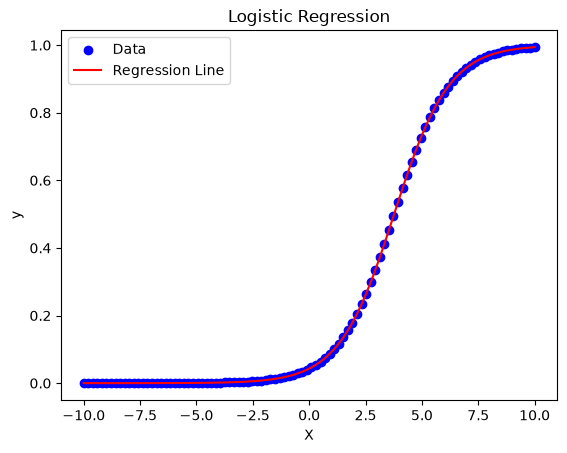

In [28]:
X = np.array([1, 2, 5, 3, 6, 2.3]).reshape(-1,1)
Y = np.array([0, 0, 1, 0, 1, 0]).reshape(-1,1)

model = LogisticRegression()
model.fit(X, Y, 0.25, 100)

x_plot = np.linspace(-10, 10, 100).reshape(-1, 1)
y_plot = model.predict(x_plot)

plt.scatter(x_plot, y_plot, color='blue', label='Data')
plt.plot(x_plot, y_plot, color='red', label='Regression Line')
plt.title("Logistic Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()